# 🌿 PLANesT-3D Point Cloud Segmentation — Analysis & Visualization
### Plant: `Ribes_04` — Semantic / Instance Segmentation + Confidence Analysis

This notebook loads a PLANesT-3D-style annotated point cloud (`.ply` + label `.txt` files)
directly from Google Drive, validates the data, and produces **publication-quality**
static figures (300 DPI, PNG + SVG) and an **interactive 3D viewer** (HTML/Plotly).

All outputs (figures, colored point clouds, CSV statistics, summary report) are
saved automatically to a structured `outputs/` folder in your Drive, ready to be
dropped into a presentation (PPTX) or a paper (LaTeX/Word).

**Pipeline**
1. Setup & Google Drive mount
2. Load `.ply` geometry + `SemanticLabels` / `InstanceLabels` / `Confidence`
3. Data validation & summary statistics
4. Publication-style multi-view figures (semantic / instance / confidence / RGB)
5. Interactive 3D viewer (Plotly, exported as standalone HTML)
6. Export colored point clouds (`.ply`) + statistics (`.csv`) + summary report (`.md`)
7. (Optional) Zip everything for one-click download

> Runtime: Colab **CPU is fine**. A GPU is not required for this pipeline.


## 1. Setup — install dependencies

In [1]:
# Core geometry / IO
!pip install -q open3d plyfile
# Interactive viz + static export of plotly figures
!pip install -q plotly kaleido
# Utilities
!pip install -q pandas numpy matplotlib seaborn tqdm
print("All dependencies installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.2 MB/s eta 0:00:00
All dependencies installed.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Configuration

Edit the paths / plant name below if you reuse this notebook for another plant
in the same `segmentation_jetcobot_internship` dataset (e.g. `Ribes_05`, `Solanum_01`, ...).

`SEMANTIC_CLASS_NAMES` maps the integer label found in `*_SemanticLabels.txt` to a
human-readable organ name. **Check this against your annotation protocol** — PLANesT-3D
typically encodes something like `0 = background/pot`, `1 = stem`, `2 = leaf`,
but confirm with `np.unique(semantic_labels)` in the validation step below before
trusting the legend on your figures.


In [3]:
import os

# --- Dataset location -------------------------------------------------------
BASE_DIR   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
PLANT_NAME = "Ribes_04"

# GT reconstruction folder
GT_DIR = os.path.join(BASE_DIR, "gt_reconstruction")

PLY_PATH        = os.path.join(GT_DIR, f"{PLANT_NAME}.ply")
SEMANTIC_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_SemanticLabels.txt")
INSTANCE_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_InstanceLabels.txt")
CONFIDENCE_PATH = os.path.join(GT_DIR, f"{PLANT_NAME}_Confidence.txt")

# --- Output location (auto-created) -----------------------------------------
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", PLANT_NAME)
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
HTML_DIR   = os.path.join(OUTPUT_DIR, "interactive")
DATA_DIR   = os.path.join(OUTPUT_DIR, "processed_data")
REPORT_DIR = os.path.join(OUTPUT_DIR, "report")

for d in [FIG_DIR, HTML_DIR, DATA_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Semantic class legend --------------------------------------------------
SEMANTIC_CLASS_NAMES = {
    0: "Background / Pot / Soil",
    1: "Stem",
    2: "Leaf",
}

# --- Visualization params ---------------------------------------------------
MAX_POINTS_FOR_STATIC_PLOTS = 250_000
MAX_POINTS_FOR_INTERACTIVE  = 120_000
RANDOM_SEED = 42

print("Base folder   :", BASE_DIR)
print("GT folder     :", GT_DIR)
print("Input PLY     :", PLY_PATH)
print("Semantic      :", SEMANTIC_PATH)
print("Instance      :", INSTANCE_PATH)
print("Confidence    :", CONFIDENCE_PATH)
print("Output folder :", OUTPUT_DIR)

Base folder   : /content/drive/MyDrive/segmentation_jetcobot_internship
GT folder     : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction
Input PLY     : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04.ply
Semantic      : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_SemanticLabels.txt
Instance      : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_InstanceLabels.txt
Confidence    : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_Confidence.txt
Output folder : /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04


## 3. Load geometry + labels

In [4]:
import numpy as np
import open3d as o3d

def load_point_cloud(path: str):
    '''Load an open3d point cloud and return (pcd, points[N,3], colors[N,3] or None).'''
    pcd = o3d.io.read_point_cloud(path)
    points = np.asarray(pcd.points, dtype=np.float64)
    colors = np.asarray(pcd.colors, dtype=np.float64) if pcd.has_colors() else None
    return pcd, points, colors

def load_label_file(path: str, dtype=np.int64) -> np.ndarray:
    '''Load a PLANesT-3D style one-value-per-line label/confidence file.'''
    arr = np.loadtxt(path, dtype=dtype)
    return arr.reshape(-1)

pcd, points, rgb_colors = load_point_cloud(PLY_PATH)
semantic_labels   = load_label_file(SEMANTIC_PATH, dtype=np.int64)
instance_labels   = load_label_file(INSTANCE_PATH, dtype=np.int64)
confidence_scores = load_label_file(CONFIDENCE_PATH, dtype=np.float64)

print(f"Points loaded              : {points.shape[0]:,}")
print(f"Has native RGB colors      : {rgb_colors is not None}")
print(f"Semantic labels length     : {semantic_labels.shape[0]:,}")
print(f"Instance labels length     : {instance_labels.shape[0]:,}")
print(f"Confidence scores length   : {confidence_scores.shape[0]:,}")


Points loaded              : 1,190,366
Has native RGB colors      : True
Semantic labels length     : 1,190,366
Instance labels length     : 1,190,366
Confidence scores length   : 1,190,366


## 4. Data validation & summary statistics

In [5]:
assert points.shape[0] == semantic_labels.shape[0] == instance_labels.shape[0] == confidence_scores.shape[0], \
    "Mismatch between number of points and number of labels — check the input files."

unique_semantic, semantic_counts = np.unique(semantic_labels, return_counts=True)
unique_instance = np.unique(instance_labels)

print("=== SEMANTIC LABELS FOUND ===")
for u, c in zip(unique_semantic, semantic_counts):
    name = SEMANTIC_CLASS_NAMES.get(int(u), f"Unknown class ({u})")
    print(f"  label {u:>3} | {name:<28} | {c:>10,} pts | {100*c/points.shape[0]:5.2f}%")

print(f"\n=== INSTANCES ===")
print(f"  Number of distinct instance IDs: {len(unique_instance)}")

print(f"\n=== CONFIDENCE ===")
print(f"  min / mean / median / max : "
      f"{confidence_scores.min():.4f} / {confidence_scores.mean():.4f} / "
      f"{np.median(confidence_scores):.4f} / {confidence_scores.max():.4f}")

print(f"\n=== BOUNDING BOX ===")
bbox_min, bbox_max = points.min(axis=0), points.max(axis=0)
print(f"  min: {bbox_min}")
print(f"  max: {bbox_max}")
print(f"  extent (x,y,z): {bbox_max - bbox_min}")


=== SEMANTIC LABELS FOUND ===
  label   1 | Stem                         |    174,696 pts | 14.68%
  label   2 | Leaf                         |  1,015,670 pts | 85.32%

=== INSTANCES ===
  Number of distinct instance IDs: 33

=== CONFIDENCE ===
  min / mean / median / max : 1.0000 / 31.0602 / 25.0000 / 177.0000

=== BOUNDING BOX ===
  min: [-6.51635005e+00  1.65052343e-01  9.22947278e-05]
  max: [15.19756825 22.32461338 34.63774085]
  extent (x,y,z): [21.7139183  22.15956103 34.63764855]


## 5. Publication-style plotting setup

Consistent, paper-ready matplotlib style (serif font, high DPI, clean 3D axes) so
every exported figure looks coherent across the whole document / slide deck.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
})
sns.set_style("white")

# A calm, print-friendly palette for plant organs (extend as needed)
SEMANTIC_PALETTE = {
    0: "#9e9e9e",  # background / pot / soil -> neutral grey
    1: "#8d5524",  # stem -> brown
    2: "#2e7d32",  # leaf -> green
}
DEFAULT_CYCLE = plt.get_cmap("tab20").colors

def semantic_color_array(labels: np.ndarray) -> np.ndarray:
    '''Map semantic label ids to RGB in [0,1] using SEMANTIC_PALETTE (fallback: tab20).'''
    uniq = np.unique(labels)
    lut = {}
    for i, u in enumerate(uniq):
        hexcol = SEMANTIC_PALETTE.get(int(u))
        lut[u] = mcolors.to_rgb(hexcol) if hexcol else DEFAULT_CYCLE[i % 20]
    return np.array([lut[l] for l in labels])

import matplotlib.colors as mcolors

def instance_color_array(labels: np.ndarray, seed: int = RANDOM_SEED) -> np.ndarray:
    '''Deterministic pseudo-random distinct color per instance id.'''
    uniq = np.unique(labels)
    rng = np.random.default_rng(seed)
    palette = rng.uniform(0.15, 0.95, size=(len(uniq), 3))
    lut = {u: palette[i] for i, u in enumerate(uniq)}
    return np.array([lut[l] for l in labels])

def subsample(n_total: int, max_points: int, seed: int = RANDOM_SEED) -> np.ndarray:
    if n_total <= max_points:
        return np.arange(n_total)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_total, max_points, replace=False))

print("Plot style ready.")


Plot style ready.


## 6. Multi-view 3D rendering helper

In [7]:
def set_equal_aspect_3d(ax, pts):
    '''Force equal XYZ scaling on a 3D axis (matplotlib does not do this by default).'''
    ranges = pts.max(axis=0) - pts.min(axis=0)
    center = (pts.max(axis=0) + pts.min(axis=0)) / 2
    r = ranges.max() / 2
    ax.set_xlim(center[0] - r, center[0] + r)
    ax.set_ylim(center[1] - r, center[1] + r)
    ax.set_zlim(center[2] - r, center[2] + r)

def plot_multiview(points, colors, title, save_stem, point_size=1.2, alpha=0.9):
    '''Render 4 canonical views (front, side, top, isometric) in one figure and save PNG+SVG.'''
    views = [
        ("Front",      0,   -90),
        ("Side",       0,     0),
        ("Top",       90,   -90),
        ("Isometric", 22,    45),
    ]
    fig = plt.figure(figsize=(18, 4.6))
    for i, (name, elev, azim) in enumerate(views):
        ax = fig.add_subplot(1, 4, i + 1, projection="3d")
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                    c=colors, s=point_size, alpha=alpha, linewidths=0)
        ax.view_init(elev=elev, azim=azim)
        set_equal_aspect_3d(ax, points)
        ax.set_title(name, pad=2)
        ax.set_axis_off()
    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"{save_stem}.png"))
    fig.savefig(os.path.join(FIG_DIR, f"{save_stem}.svg"))
    plt.show()
    return fig

def add_legend(ax_or_fig, color_lut, name_lut=None, title="Legend", loc="upper right"):
    handles = [
        mpatches.Patch(color=color_lut[k], label=(name_lut.get(int(k), str(k)) if name_lut else str(k)))
        for k in sorted(color_lut.keys())
    ]
    ax_or_fig.legend(handles=handles, title=title, loc=loc, frameon=True, framealpha=0.95)

print("Rendering helpers ready.")


Rendering helpers ready.


## 7. Figure 1 — Original RGB point cloud (if available)

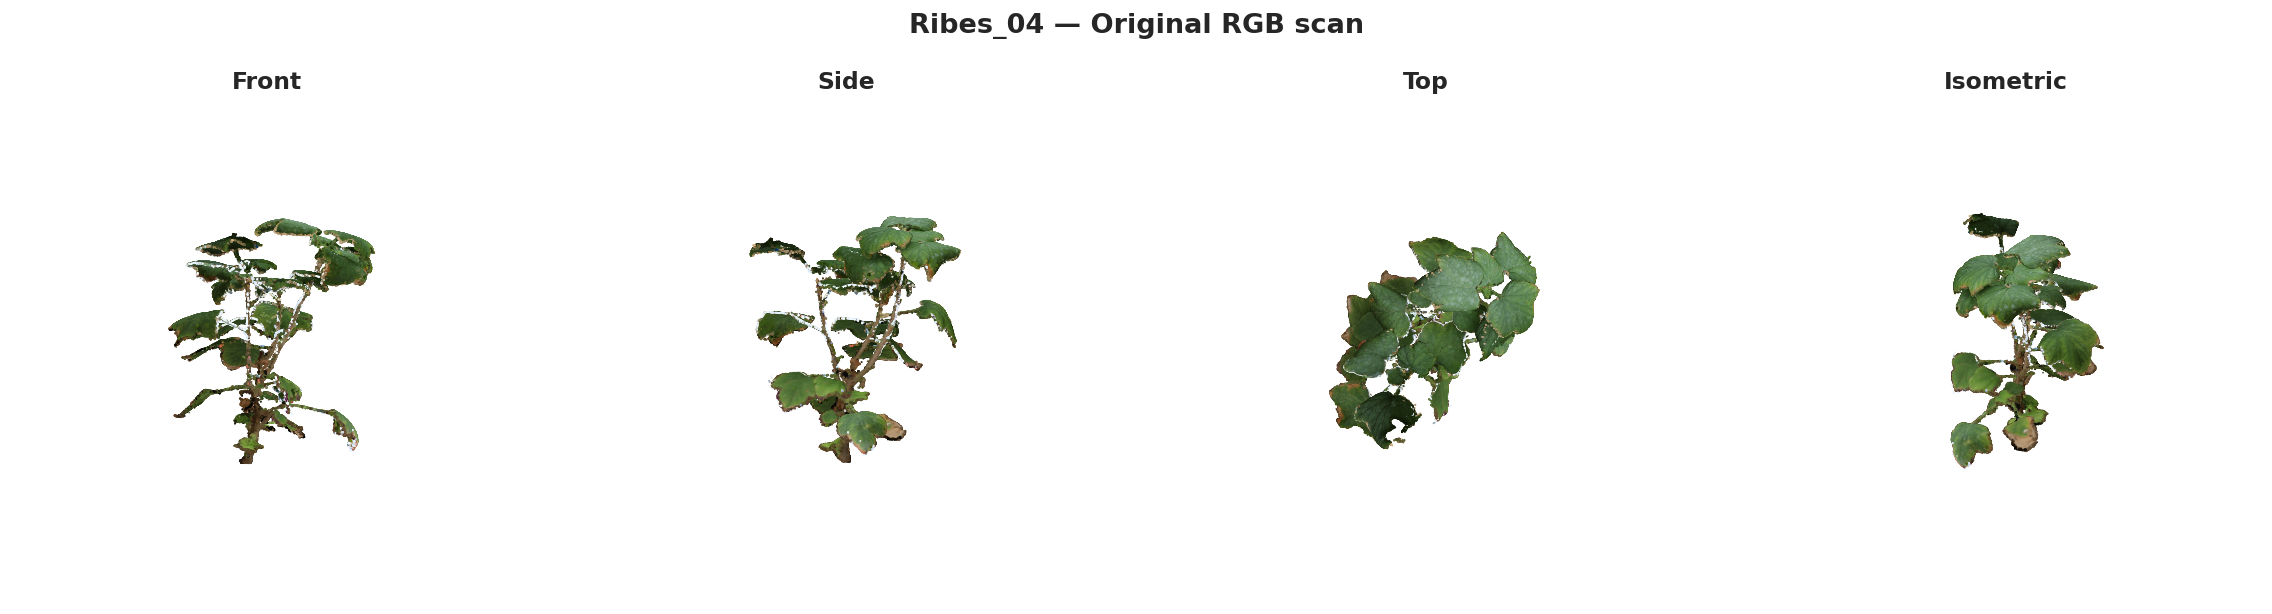

In [8]:
idx_static = subsample(points.shape[0], MAX_POINTS_FOR_STATIC_PLOTS)

if rgb_colors is not None:
    plot_multiview(
        points[idx_static], rgb_colors[idx_static],
        title=f"{PLANT_NAME} — Original RGB scan",
        save_stem="01_original_rgb",
        point_size=1.0,
    )
else:
    print("No native RGB colors stored in the .ply — skipping this figure.")


## 8. Figure 2 — Semantic segmentation

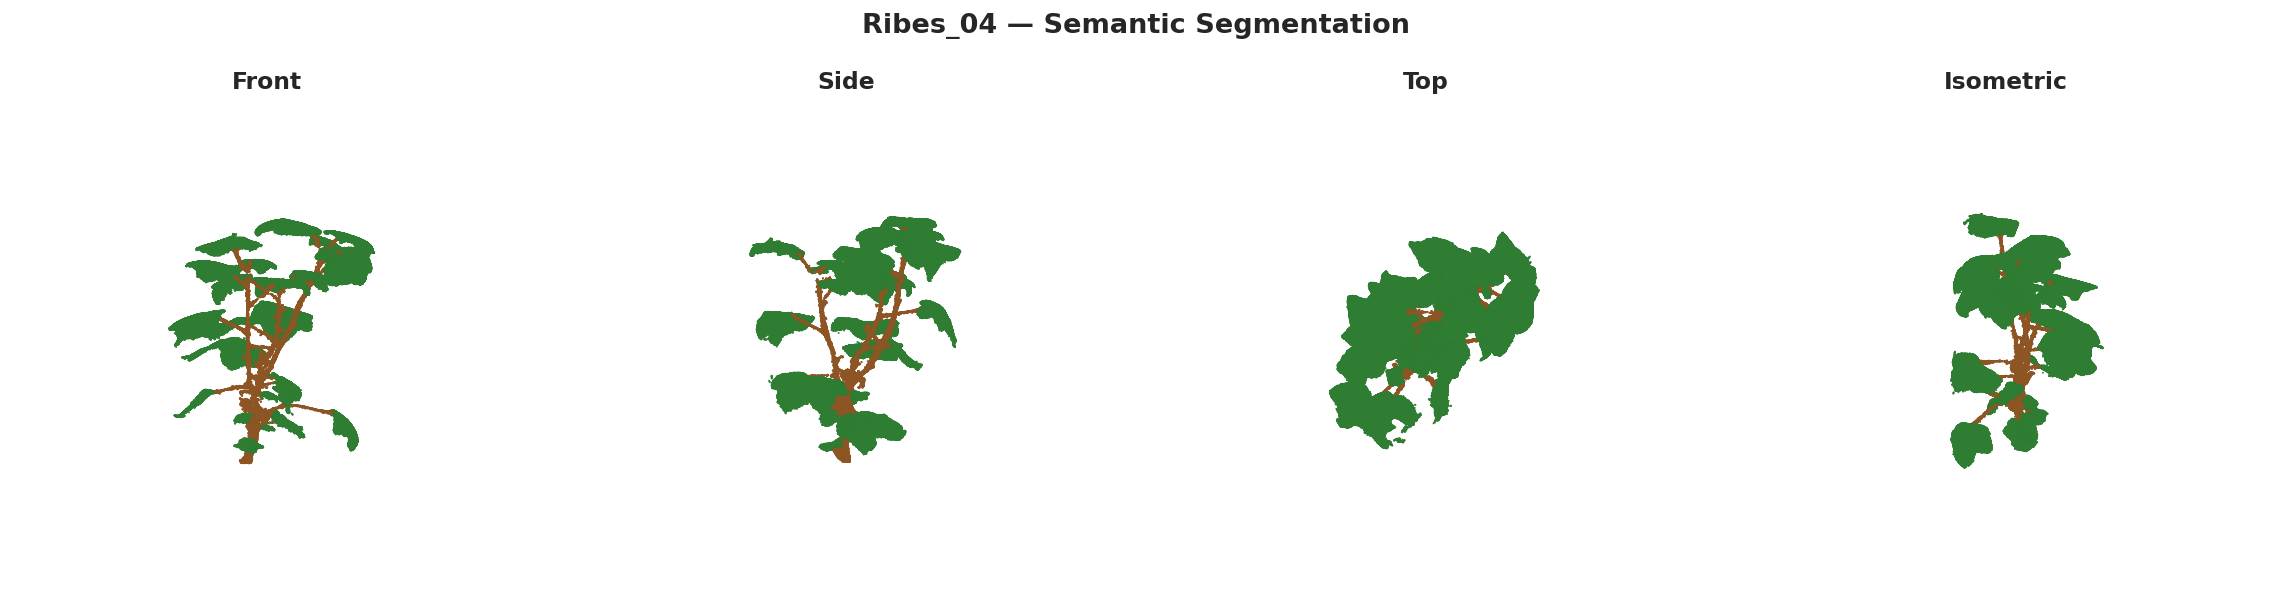

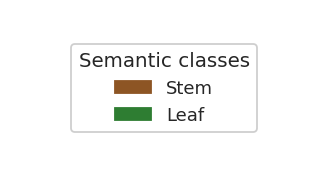

In [9]:
sem_colors_full = semantic_color_array(semantic_labels)

fig = plot_multiview(
    points[idx_static], sem_colors_full[idx_static],
    title=f"{PLANT_NAME} — Semantic Segmentation",
    save_stem="02_semantic_segmentation",
    point_size=1.2,
)

# Standalone legend figure (handy to drop separately into slides)
color_lut = {u: mcolors.to_rgb(SEMANTIC_PALETTE.get(int(u), DEFAULT_CYCLE[i % 20]))
             for i, u in enumerate(unique_semantic)}
fig_leg = plt.figure(figsize=(3, 1.5))
add_legend(plt, color_lut, SEMANTIC_CLASS_NAMES, title="Semantic classes", loc="center")
plt.axis("off")
fig_leg.savefig(os.path.join(FIG_DIR, "02_semantic_legend.png"), bbox_inches="tight")
fig_leg.savefig(os.path.join(FIG_DIR, "02_semantic_legend.svg"), bbox_inches="tight")
plt.show()


## 9. Figure 3 — Instance segmentation

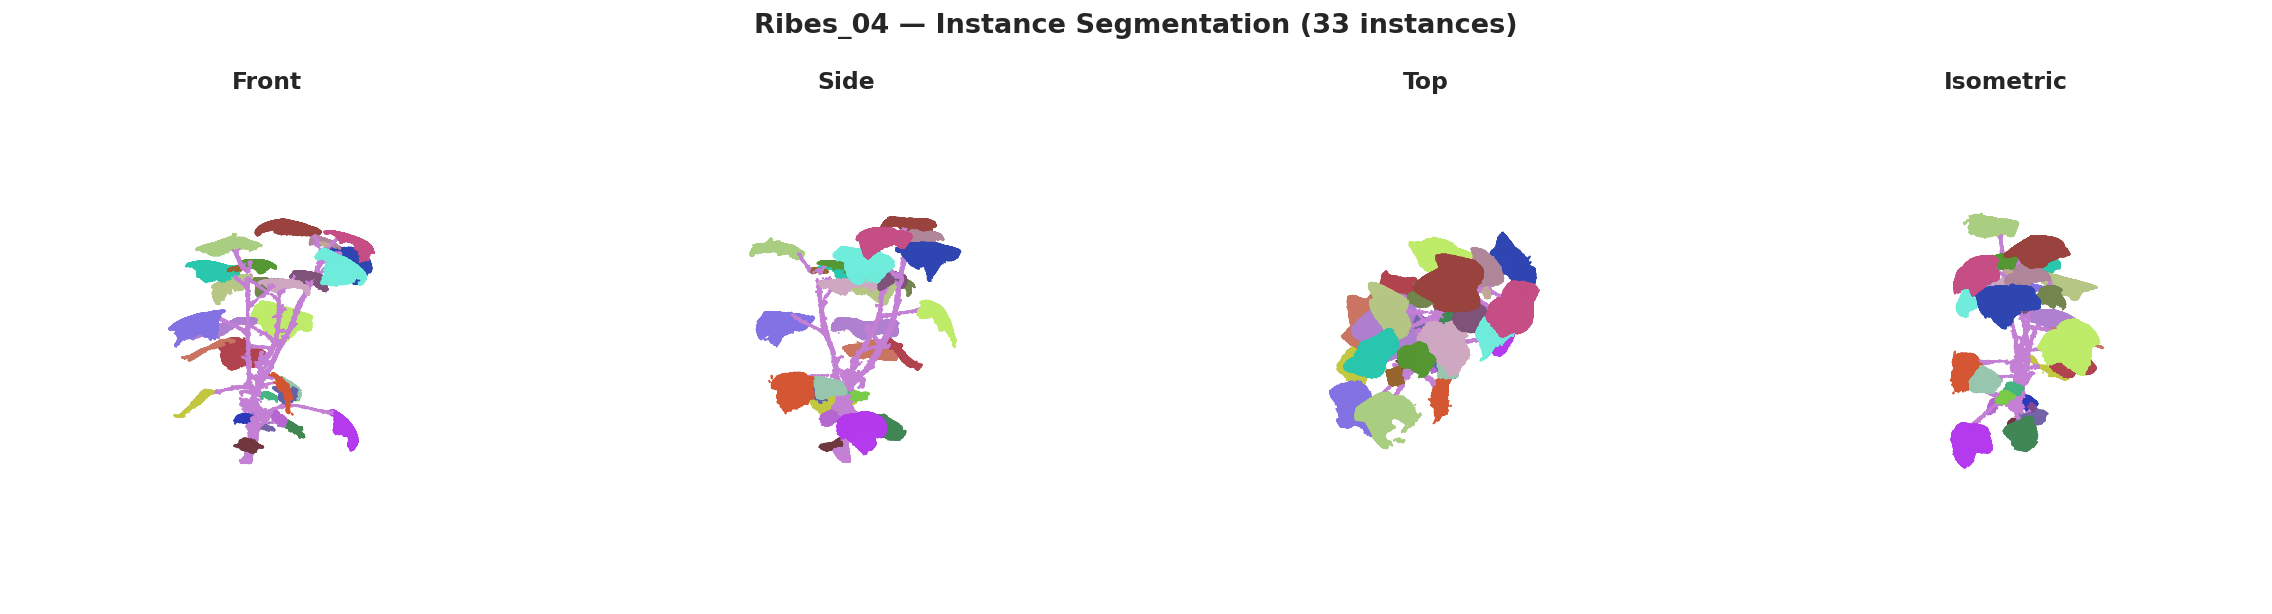

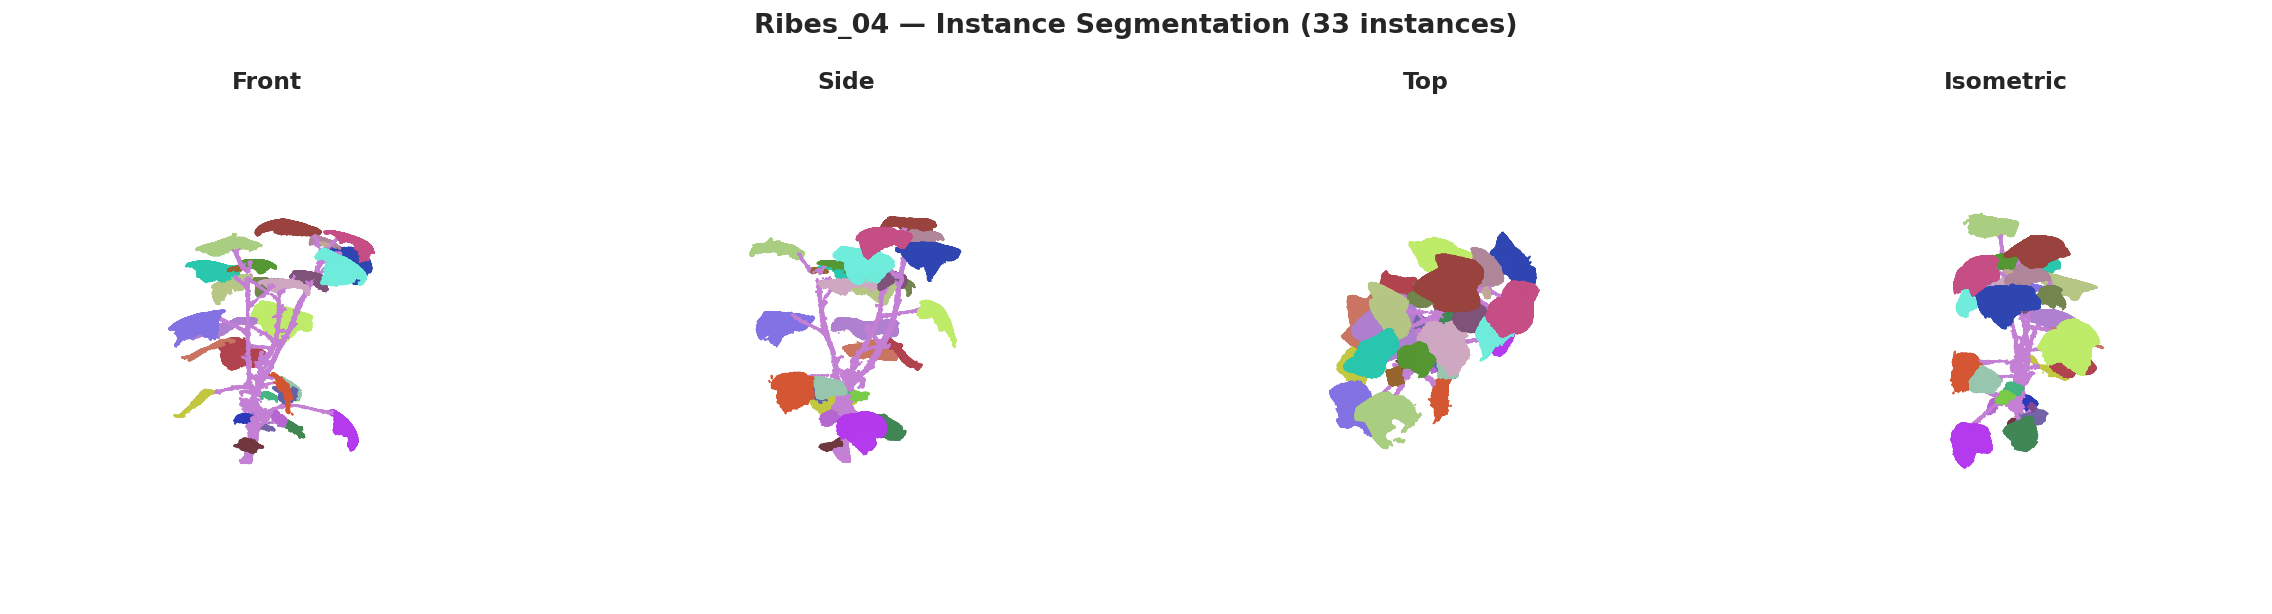

In [10]:
inst_colors_full = instance_color_array(instance_labels)

plot_multiview(
    points[idx_static], inst_colors_full[idx_static],
    title=f"{PLANT_NAME} — Instance Segmentation ({len(unique_instance)} instances)",
    save_stem="03_instance_segmentation",
    point_size=1.2,
)


## 10. Figure 4 — Confidence heatmap

In [ ]:
fig = plt.figure(figsize=(18, 4.6))
views = [("Front", 0, -90), ("Side", 0, 0), ("Top", 90, -90), ("Isometric", 22, 45)]
sc = None
for i, (name, elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    sc = ax.scatter(points[idx_static, 0], points[idx_static, 1], points[idx_static, 2],
                     c=confidence_scores[idx_static], cmap="viridis", vmin=0, vmax=1,
                     s=1.2, linewidths=0)
    ax.view_init(elev=elev, azim=azim)
    set_equal_aspect_3d(ax, points[idx_static])
    ax.set_title(name, pad=2)
    ax.set_axis_off()
fig.suptitle(f"{PLANT_NAME} — Prediction Confidence", fontsize=15, fontweight="bold", y=1.02)
cbar = fig.colorbar(sc, ax=fig.axes, shrink=0.6, pad=0.02, label="Confidence")
fig.savefig(os.path.join(FIG_DIR, "04_confidence_heatmap.png"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "04_confidence_heatmap.svg"), bbox_inches="tight")
plt.show()


## 11. Figure 5 — Class distribution & confidence-per-class (summary charts)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Bar chart: point count per semantic class ---
labels_txt = [SEMANTIC_CLASS_NAMES.get(int(u), str(u)) for u in unique_semantic]
bar_colors = [SEMANTIC_PALETTE.get(int(u), "#888888") for u in unique_semantic]
axes[0].bar(labels_txt, semantic_counts, color=bar_colors, edgecolor="black", linewidth=0.6)
axes[0].set_ylabel("Number of points")
axes[0].set_title("Point distribution per semantic class")
for tick in axes[0].get_xticklabels():
    tick.set_rotation(20)
    tick.set_ha("right")
for x, c in enumerate(semantic_counts):
    axes[0].text(x, c, f"{100*c/points.shape[0]:.1f}%", ha="center", va="bottom", fontsize=9)

# --- Box plot: confidence distribution per class ---
data_per_class = [confidence_scores[semantic_labels == u] for u in unique_semantic]
bp = axes[1].boxplot(data_per_class, labels=labels_txt, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], bar_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Confidence score")
axes[1].set_title("Confidence distribution per semantic class")
for tick in axes[1].get_xticklabels():
    tick.set_rotation(20)
    tick.set_ha("right")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_class_distribution_summary.png"))
fig.savefig(os.path.join(FIG_DIR, "05_class_distribution_summary.svg"))
plt.show()


## 12. Interactive 3D viewer (Plotly)

Rotate / zoom / hover directly in the notebook, and a standalone `.html` is saved
to Drive so you (or a supervisor/reviewer) can open it in any browser without Colab.


In [ ]:
import plotly.graph_objects as go

idx_interactive = subsample(points.shape[0], MAX_POINTS_FOR_INTERACTIVE)
p = points[idx_interactive]

hover_text = [
    f"semantic: {SEMANTIC_CLASS_NAMES.get(int(s), s)}<br>instance: {i}<br>confidence: {c:.3f}"
    for s, i, c in zip(semantic_labels[idx_interactive],
                        instance_labels[idx_interactive],
                        confidence_scores[idx_interactive])
]

sem_rgb_255 = (semantic_color_array(semantic_labels[idx_interactive]) * 255).astype(int)
sem_color_strings = [f"rgb({r},{g},{b})" for r, g, b in sem_rgb_255]

fig = go.Figure(data=[go.Scatter3d(
    x=p[:, 0], y=p[:, 1], z=p[:, 2],
    mode="markers",
    marker=dict(size=1.6, color=sem_color_strings, opacity=0.9),
    text=hover_text,
    hoverinfo="text",
)])
fig.update_layout(
    title=f"{PLANT_NAME} — Interactive Semantic Segmentation",
    scene=dict(
        xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    template="plotly_white",
)
fig.write_html(os.path.join(HTML_DIR, f"{PLANT_NAME}_interactive_semantic.html"))
fig.show()


## 13. Export colored point clouds (.ply) for MeshLab / CloudCompare / slides

In [ ]:
def save_colored_ply(points, colors_float01, out_path):
    out = o3d.geometry.PointCloud()
    out.points = o3d.utility.Vector3dVector(points)
    out.colors = o3d.utility.Vector3dVector(np.clip(colors_float01, 0, 1))
    o3d.io.write_point_cloud(out_path, out)
    print("Saved:", out_path)

save_colored_ply(points, sem_colors_full,  os.path.join(DATA_DIR, f"{PLANT_NAME}_semantic_colored.ply"))
save_colored_ply(points, inst_colors_full, os.path.join(DATA_DIR, f"{PLANT_NAME}_instance_colored.ply"))

conf_norm = (confidence_scores - confidence_scores.min()) / (np.ptp(confidence_scores) + 1e-9)
conf_colors = plt.get_cmap("viridis")(conf_norm)[:, :3]
save_colored_ply(points, conf_colors, os.path.join(DATA_DIR, f"{PLANT_NAME}_confidence_colored.ply"))


Saved: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/processed_data/Ribes_04_semantic_colored.ply
Saved: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/processed_data/Ribes_04_instance_colored.ply
Saved: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/processed_data/Ribes_04_confidence_colored.ply


## 14. Export tabular statistics (.csv) — ready for LaTeX/Excel tables

In [ ]:
import pandas as pd

# Per-point table (subsampled, to keep the CSV manageable for a paper appendix)
idx_csv = subsample(points.shape[0], 100_000)
df_points = pd.DataFrame({
    "x": points[idx_csv, 0], "y": points[idx_csv, 1], "z": points[idx_csv, 2],
    "semantic_label": semantic_labels[idx_csv],
    "semantic_name": [SEMANTIC_CLASS_NAMES.get(int(s), str(s)) for s in semantic_labels[idx_csv]],
    "instance_id": instance_labels[idx_csv],
    "confidence": confidence_scores[idx_csv],
})
df_points.to_csv(os.path.join(DATA_DIR, f"{PLANT_NAME}_points_sample.csv"), index=False)

# Per-class summary table (this is the one you likely want directly in the paper)
df_summary = pd.DataFrame({
    "label_id": unique_semantic,
    "class_name": labels_txt,
    "n_points": semantic_counts,
    "pct_points": 100 * semantic_counts / points.shape[0],
    "mean_confidence": [confidence_scores[semantic_labels == u].mean() for u in unique_semantic],
    "median_confidence": [np.median(confidence_scores[semantic_labels == u]) for u in unique_semantic],
})
df_summary.to_csv(os.path.join(DATA_DIR, f"{PLANT_NAME}_class_summary.csv"), index=False)
df_summary


,label_id,class_name,n_points,pct_points,mean_confidence,median_confidence
0,1,Stem,174696,14.675822,3.593105,2.0
1,2,Leaf,1015670,85.324178,35.784585,34.0


## 15. Auto-generated summary report (Markdown) — copy straight into your paper

In [ ]:
report_path = os.path.join(REPORT_DIR, f"{PLANT_NAME}_summary_report.md")

lines = []
lines.append(f"# Segmentation Summary — {PLANT_NAME}\n")
lines.append(f"- Total points: **{points.shape[0]:,}**")
lines.append(f"- Bounding box extent (x,y,z): {np.round(bbox_max - bbox_min, 3).tolist()}")
lines.append(f"- Number of semantic classes: **{len(unique_semantic)}**")
lines.append(f"- Number of instances: **{len(unique_instance)}**")
lines.append(f"- Confidence — mean: {confidence_scores.mean():.4f}, "
             f"median: {np.median(confidence_scores):.4f}, "
             f"min: {confidence_scores.min():.4f}, max: {confidence_scores.max():.4f}\n")
lines.append("## Per-class breakdown\n")
lines.append("| Label | Class | Points | % of cloud | Mean confidence |")
lines.append("|---|---|---:|---:|---:|")
for _, r in df_summary.iterrows():
    lines.append(f"| {int(r.label_id)} | {r.class_name} | {int(r.n_points):,} | "
                 f"{r.pct_points:.2f}% | {r.mean_confidence:.4f} |")

with open(report_path, "w") as f:
    f.write("\n".join(lines))

print(f"Report saved to: {report_path}\n")
print("\n".join(lines))


Report saved to: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/report/Ribes_04_summary_report.md

# Segmentation Summary — Ribes_04

- Total points: **1,190,366**
- Bounding box extent (x,y,z): [21.714, 22.16, 34.638]
- Number of semantic classes: **2**
- Number of instances: **33**
- Confidence — mean: 31.0602, median: 25.0000, min: 1.0000, max: 177.0000

## Per-class breakdown

| Label | Class | Points | % of cloud | Mean confidence |
|---|---|---:|---:|---:|
| 1 | Stem | 174,696 | 14.68% | 3.5931 |
| 2 | Leaf | 1,015,670 | 85.32% | 35.7846 |


## 16. (Optional) Zip all outputs for a one-click download

In [ ]:
import shutil

zip_path = shutil.make_archive(
    base_name=os.path.join(OUTPUT_DIR, f"{PLANT_NAME}_outputs"),
    format="zip",
    root_dir=OUTPUT_DIR,
    base_dir=".",
)
print("Zip archive saved to:", zip_path)

# Uncomment to download directly to your machine from Colab:
# from google.colab import files
# files.download(zip_path)


## ✅ Done

Everything is saved under:
```
segmentation_jetcobot_internship/outputs/Ribes_04/
├── figures/            (PNG @300dpi + SVG — for the paper / slides)
├── interactive/         (standalone HTML 3D viewer)
├── processed_data/      (colored .ply files + .csv tables)
└── report/               (auto-generated Markdown summary)
```

**Tips for your presentation / paper**
- Use the `figures/*.svg` for LaTeX (vector, scales cleanly) and `*.png` for PowerPoint/Keynote.
- `02_semantic_legend.*` is a standalone legend you can place next to a cropped screenshot.
- `*_class_summary.csv` maps directly to a LaTeX `\begin{tabular}` or an Excel/Word table.
- The interactive `.html` is great for a supplementary link or a QR code on a poster.
- To process another plant, just change `PLANT_NAME` in **Section 2** and re-run all cells.
